##  ***Hull-White Model Calibration & Pricing***



In [ ]:
from curve_builder import Curve
from hw_pricer import HullWhitePricer
from calibration import HullWhiteCalibrator

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

### ***0. Functions:***

In [2]:
# Bachelier (normal) vol from price
def black_normal_vol(price, forward, strike, expiry, notional, annuity):
    """
    Computes the normal (Bachelier) implied volatility (in basis points) from a swaption or caplet price.

    Parameters
    ----------
    price : float
        Market price of the swaption or caplet.
    forward : float
        Forward swap rate.
    strike : float
        Swaption strike rate.
    expiry : float
        Time to expiry in years.
    notional : float
        Notional amount of the swaption or caplet.
    annuity : float
        Annuity factor for the swaption or caplet (DF x Year Frac.).

    Returns
    -------
    float
        Implied normal volatility in basis points (bps).
    """
    forward = forward / 100  # convert percentage to rate units
    strike = strike / 100    # convert percentage to rate units

    def bachelier_price(sigma):
        if sigma <= 0:
            return 0.0
        d = (forward - strike) / (sigma * np.sqrt(expiry))
        price_model = annuity * notional * ((forward - strike) * norm.cdf(d) + sigma * np.sqrt(expiry) * norm.pdf(d))
        return price_model

    def objective(sigma):
        return bachelier_price(sigma) - price

    # Reasonable bounds for normal vols (in rate units)
    try:
        sigma_normal = brentq(objective, 1e-6, 5.0)
    except:
        sigma_normal = np.nan
    return sigma_normal * 10000  # convert to bps

### ***1. Market Curves (USD):***

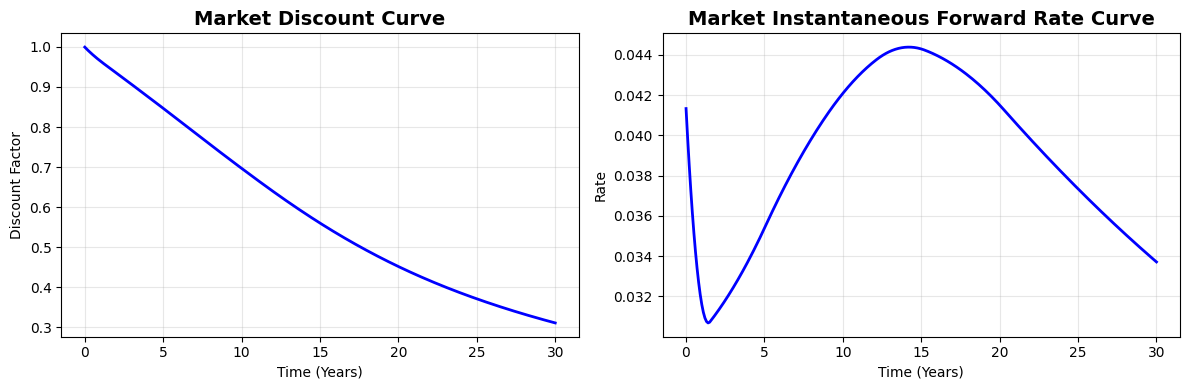

In [3]:
# Discount curve data
file = r'SWPN_Calibration_Template_30092025.xlsx'

input_curve = pd.read_excel(file, sheet_name ='Curve')
time = input_curve['Year_Frac']
disc_rate = input_curve['Discount_Factor']
curve = Curve(time, disc_rate)

# Market Curves Plot 
t = np.linspace(0.01, 30, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t, curve.discount(t), 'b-', linewidth=2)
axes[0].set_title('Market Discount Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (Years)', fontsize=10)
axes[0].set_ylabel('Discount Factor', fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(t, curve.inst_forward_rate(t), 'b-', linewidth=2)
axes[1].set_title('Market Instantaneous Forward Rate Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (Years)', fontsize=10)
axes[1].set_ylabel('Rate', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ***2. Swaption Calibration (USD):***

In [4]:
# Calibration 
df = pd.read_excel(file, sheet_name = 'Template')
df['Payment_Dates'] = [[float(x) for x in eval(item)] for item in df['Payment_Dates'].tolist()]

market_prices = {
    'Prices': df['Price'].tolist(),
    'Strike': df['Strike'].tolist(),
    'Notional': df['Notional'].tolist(),
    'Dates': df['Payment_Dates'].tolist()}

# Initialize pricer and calibrator, and calibrate to market
pricer = HullWhitePricer(curve)
calibrator = HullWhiteCalibrator(pricer, market_prices, calibrate_to = 'Swaptions', a_fixed = 0.01)
result = calibrator.calibrate()

a fixed: 0.010000, sigma: 0.008486, RMSRE: 2.66107e-02
a fixed: 0.010000, sigma: 0.008567, RMSRE: 2.46375e-02
a fixed: 0.010000, sigma: 0.008574, RMSRE: 2.46266e-02
a fixed: 0.010000, sigma: 0.008573, RMSRE: 2.46265e-02
a fixed: 0.010000, sigma: 0.008573, RMSRE: 2.46265e-02

Calibration successful:
Iterations: 5
Number of instruments: 208
Total Error:  +2.463%

Parameters:
Fixed a: 0.01000
Optimal sigma: 0.00857

Swaption   0:  1.01Y to 2.01 Y | Model:    34.05 | Market:    32.38 | Diff:  +5.183%
Swaption   1:  1.52Y to 2.52 Y | Model:    41.48 | Market:    40.51 | Diff:  +2.403%
Swaption   2:  2.03Y to 3.03 Y | Model:    47.87 | Market:    47.42 | Diff:  +0.947%
Swaption   3:  3.04Y to 4.04 Y | Model:    58.32 | Market:    58.80 | Diff:  -0.818%
Swaption   4:  4.05Y to 5.05 Y | Model:    66.94 | Market:    67.93 | Diff:  -1.449%
Swaption   5:  5.07Y to 6.07 Y | Model:    74.57 | Market:    75.84 | Diff:  -1.680%
Swaption   6:  7.10Y to 8.10 Y | Model:    87.44 | Market:    88.94 | Dif

### ***3. Calibration Results:*** 

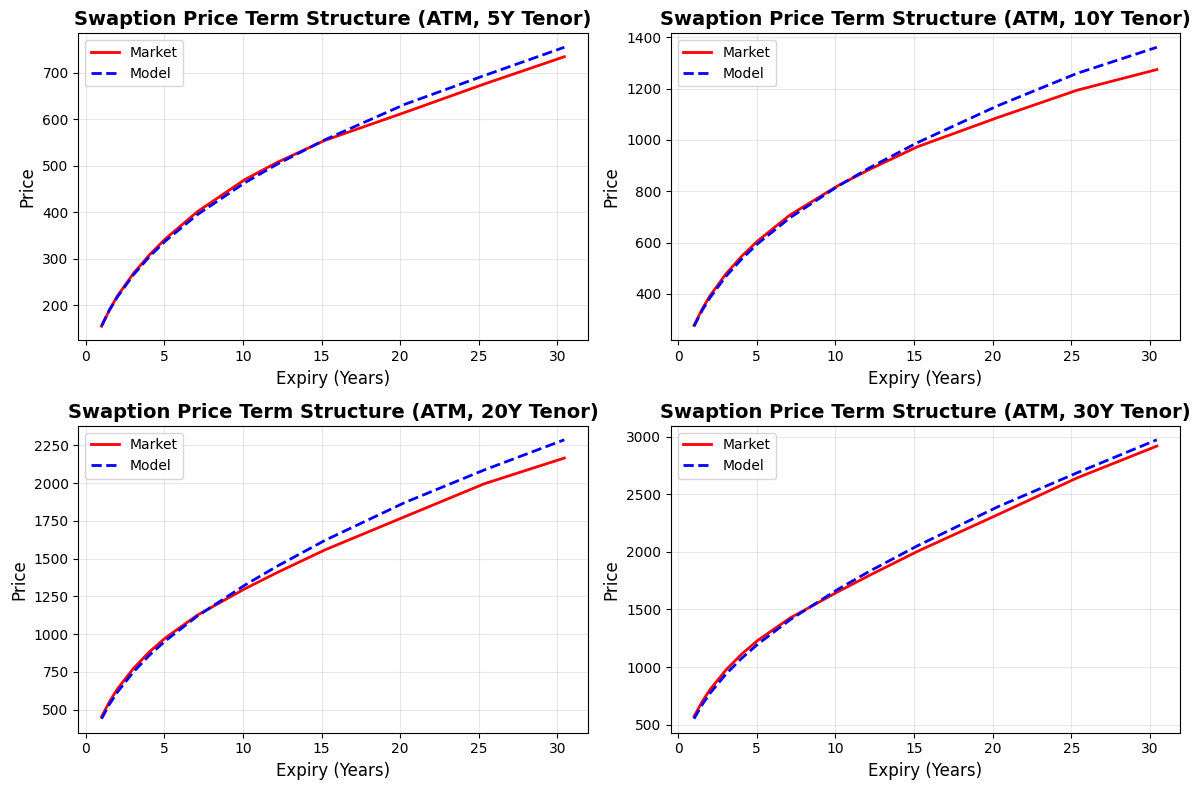

In [5]:
df['Model_Price'] = [pricer.swaption(df['Payment_Dates'][i], df['Notional'][i], df['Strike'][i]/100)/curve.discount(df['Expiry'][i]) for i in range(len(df))]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
Tenors = [5.0, 10.0, 20.0, 30.0]
axes = axes.flatten()

for idx, tenor in enumerate(Tenors):
    df_tenor = df[df['Tenor'] == tenor]
    T_vals = df_tenor['Expiry']
    model_price = df_tenor['Model_Price']
    market_price = df_tenor['Price']

    axes[idx].plot(T_vals, market_price, 'r-', linewidth=2, label='Market')
    axes[idx].plot(T_vals, model_price, 'b--', linewidth=2, label='Model')
    axes[idx].set_title(f'Swaption Price Term Structure (ATM, {int(tenor)}Y Tenor)', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Expiry (Years)', fontsize=12)
    axes[idx].set_ylabel('Price', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=10)

plt.tight_layout()
plt.show()

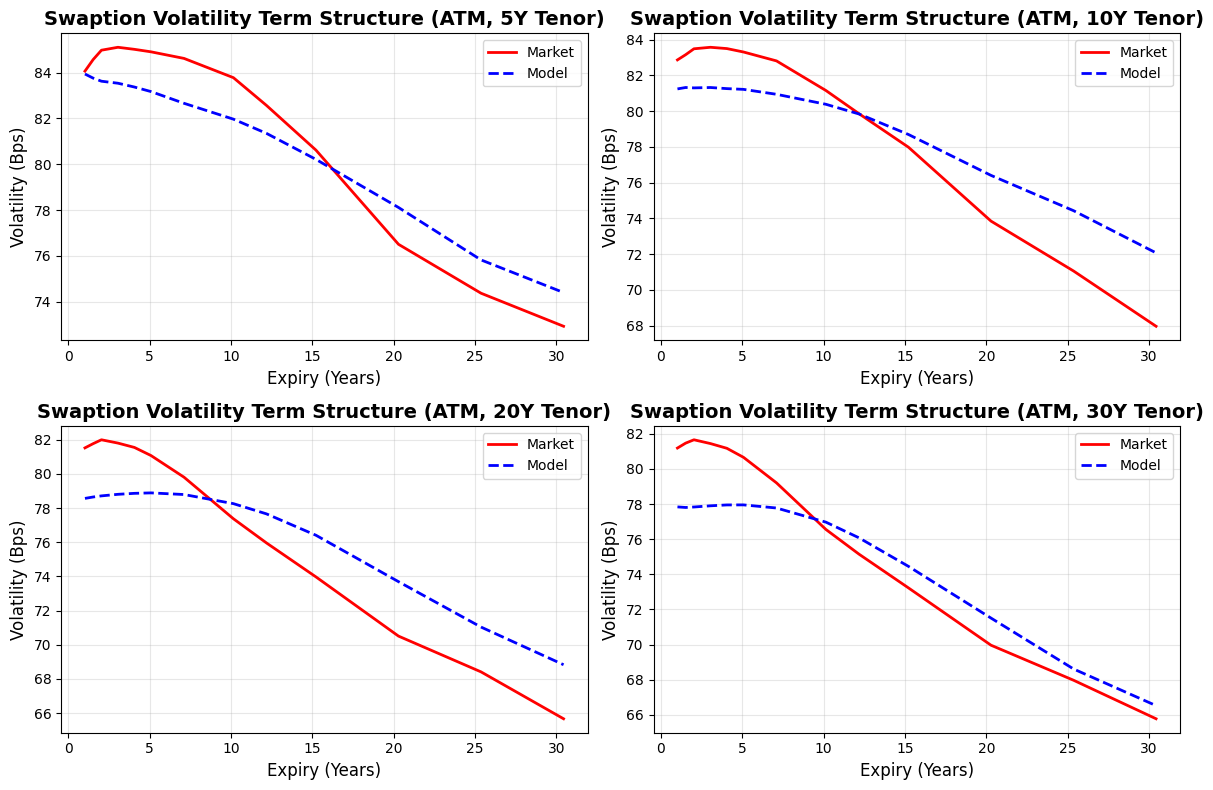

In [6]:
df['Model_Vol (Bps)'] = [black_normal_vol(df['Model_Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], df['Notional'][i], df['Duration'][i]) for i in range(len(df))]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
Tenors = [5.0, 10.0, 20.0, 30.0]
axes = axes.flatten()

for idx, tenor in enumerate(Tenors):
    df_tenor = df[df['Tenor'] == tenor]
    T_vals = df_tenor['Expiry']
    model_vol = df_tenor['Model_Vol (Bps)']
    market_vol = df_tenor['Volatility (Bps)']

    axes[idx].plot(T_vals, market_vol, 'r-', linewidth=2, label='Market')
    axes[idx].plot(T_vals, model_vol, 'b--', linewidth=2, label='Model')
    axes[idx].set_title(f'Swaption Volatility Term Structure (ATM, {int(tenor)}Y Tenor)', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Expiry (Years)', fontsize=12)
    axes[idx].set_ylabel('Volatility (Bps)', fontsize=12)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=10)

plt.tight_layout()
plt.show()

### ***4. Simulation of Market-Consistent Escenarios:***

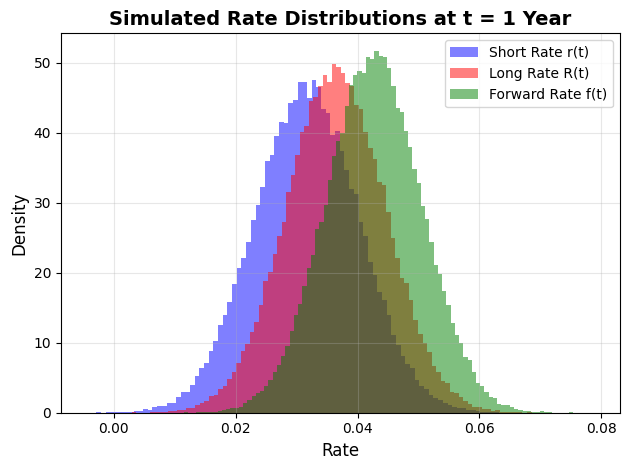

In [7]:
# Simulations
pricer.set_simulation(n_paths = 10**5)
r_t = pricer.curve_sim.short_rate(t = 1) 
R_t = pricer.curve_sim.long_rate(t = 1, T = 10)
f_t = pricer.curve_sim.inst_forward_rate(t = 1, T = 10)

# Plot in the same figure
plt.hist(r_t, bins=100, density=True, alpha=0.5, color='b', label='Short Rate r(t)')
plt.hist(R_t, bins=100, density=True, alpha=0.5, color='r', label='Long Rate R(t)')
plt.hist(f_t, bins=100, density=True, alpha=0.5, color='g', label='Forward Rate f(t)')
plt.title('Simulated Rate Distributions at t = 1 Year', fontsize=14, fontweight='bold')
plt.xlabel('Rate', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ***5. Caplets Calibration (USD):***

In [8]:
# Market Prices
file = r'CAP_Calibration_Template_30092025.xlsx'
df = pd.read_excel(file, sheet_name ='Template')

market_prices = {
    'Prices': df['Price'].tolist(),
    'Strike': df['Strike'].tolist(),
    'Notional': df['Notional'].tolist(),
    'Expiry': df['Expiry'].tolist(),
    'Maturity': df['Maturity'].tolist()}

# Initialize pricer and calibrator, and calibrate to market
pricer = HullWhitePricer(curve)
calibrator = HullWhiteCalibrator(pricer, market_prices)
result = calibrator.calibrate()

a fixed: 0.010000, sigma: 0.000100, RMSRE: 9.60753e-01
a fixed: 0.010000, sigma: 0.008953, RMSRE: 2.34570e-02
a fixed: 0.010000, sigma: 0.009029, RMSRE: 2.32537e-02
a fixed: 0.010000, sigma: 0.008996, RMSRE: 2.29625e-02
a fixed: 0.010000, sigma: 0.008996, RMSRE: 2.29625e-02
a fixed: 0.010000, sigma: 0.008996, RMSRE: 2.29625e-02

Calibration successful:
Iterations: 6
Number of instruments: 48
Total Error:  +2.296%

Parameters:
Fixed a: 0.01000
Optimal sigma: 0.00900

Caplet  0:  1.02Y to 1.52 Y | Model:    20.40 | Market:    19.75 | Diff:  +3.306%
Caplet  1:  1.52Y to 2.02 Y | Model:    23.17 | Market:    23.32 | Diff:  -0.616%
Caplet  2:  2.04Y to 2.54 Y | Model:    27.65 | Market:    27.80 | Diff:  -0.537%
Caplet  3:  3.05Y to 3.55 Y | Model:    23.99 | Market:    24.73 | Diff:  -2.969%
Caplet  4:  3.56Y to 4.06 Y | Model:    27.08 | Market:    27.92 | Diff:  -3.010%
Caplet  5:  4.06Y to 4.56 Y | Model:    29.95 | Market:    30.64 | Diff:  -2.252%
Caplet  6:  4.57Y to 5.07 Y | Model: 

### ***6. Calibration Results:***

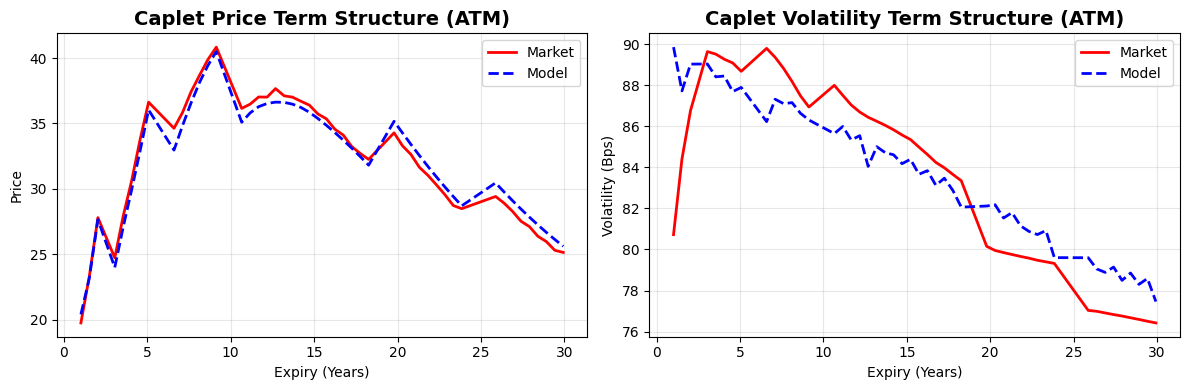

In [9]:
# Plot differences between model and market volatilities
df['Model Price'] = [pricer.caplet(df['Expiry'][i], df['Maturity'][i], df['Notional'][i], df['Strike'][i]/100) for i in range(len(df))]
df['Model Vol'] = [black_normal_vol(df['Model Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], df['Notional'][i], df['Duration'][i]) for i in range(len(df))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# price plot 
axes[0].plot(df['Expiry'], df['Price'], 'r-', linewidth=2, label='Market')
axes[0].plot(df['Expiry'], df['Model Price'], 'b--', linewidth=2, label='Model')
axes[0].set_title('Caplet Price Term Structure (ATM)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Expiry (Years)', fontsize=10)
axes[0].set_ylabel('Price', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)

# Volatility Plot
axes[1].plot(df['Expiry'], df['Volatility (Bps)'], 'r-', linewidth=2, label='Market')
axes[1].plot(df['Expiry'], df['Model Vol'], 'b--', linewidth=2, label='Model')
axes[1].set_title('Caplet Volatility Term Structure (ATM)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Expiry (Years)')
axes[1].set_ylabel('Volatility (Bps)')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

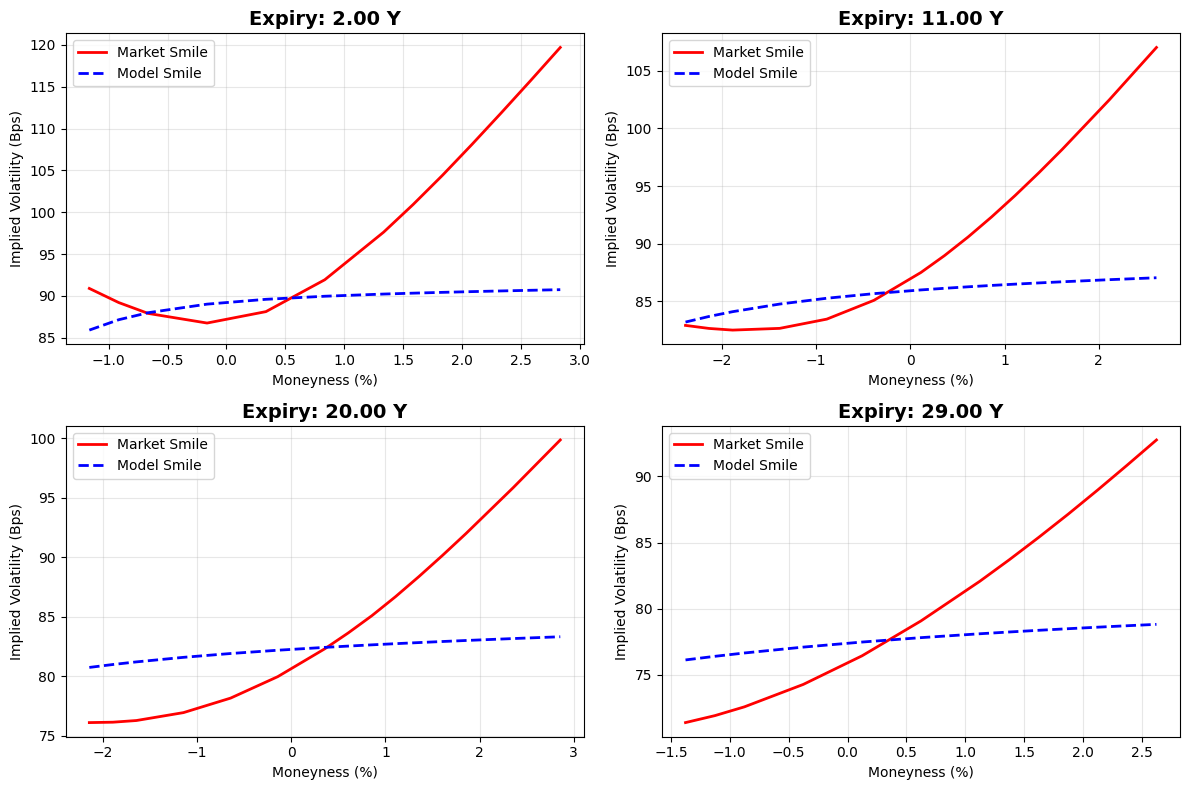

In [10]:
# OTM caplets data
file = r'CAP_Market_Data_30092025.xlsx'
df_mkt = pd.read_excel(file)

Moneyness = 3.0; Notional = 10_000; Tenor = 6.0

mask1 = df_mkt['Opt_Type'] == 'Caplet'
mask2 = df_mkt['Tenor']  == Tenor
mask3 = df_mkt['Moneyness'].abs() < Moneyness 

df = df_mkt[mask1 & mask2 & mask3].copy().reset_index(drop=True)
df['Model Price'] = [pricer.caplet(df['Expiry'][i], df['Maturity'][i], Notional, df['Strike'][i]/100) for i in range(len(df))]
df['Model Vol'] = [black_normal_vol(df['Model Price'][i], df['Forward'][i], df['Strike'][i], df['Expiry'][i], Notional, df['Duration'][i]) for i in range(len(df))] 

df_smile = df[['Volatility (Bps)', 'Moneyness', 'Expiry', 'Model Vol']].sort_values(by='Moneyness').dropna().reset_index(drop=True)
expiries = df_smile['Expiry'].sort_values().unique()

# Subplots for various expiries
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axs = axs.flatten()

exp_indices = np.linspace(4, len(expiries) - 1, 4, dtype=int)
for ax, idx in zip(axs, exp_indices):
    expiry = expiries[idx]
    mask = df_smile['Expiry'] == expiry
    ax.plot(df_smile['Moneyness'][mask], df_smile['Volatility (Bps)'][mask], 'r-', linewidth = 2, label='Market Smile')
    ax.plot(df_smile['Moneyness'][mask], df_smile['Model Vol'][mask], 'b--', linewidth = 2, label='Model Smile')
    ax.set_title(f'Expiry: {int(expiry):.2f} Y', fontsize=14, fontweight='bold')
    ax.set_xlabel('Moneyness (%)')
    ax.set_ylabel('Implied Volatility (Bps)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()